In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/heart-failure-prediction/heart.csv


In [2]:
data=pd.read_csv('/kaggle/input/heart-failure-prediction/heart.csv')
data

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1


In [3]:
data.dtypes

Age                 int64
Sex                object
ChestPainType      object
RestingBP           int64
Cholesterol         int64
FastingBS           int64
RestingECG         object
MaxHR               int64
ExerciseAngina     object
Oldpeak           float64
ST_Slope           object
HeartDisease        int64
dtype: object

In [4]:
data.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [5]:
x =data.iloc[:,0:11]
x

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up
...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat


In [6]:
y=data['HeartDisease']
y

0      0
1      1
2      0
3      1
4      0
      ..
913    1
914    1
915    1
916    1
917    0
Name: HeartDisease, Length: 918, dtype: int64

In [7]:
data.Age.unique()

array([40, 49, 37, 48, 54, 39, 45, 58, 42, 38, 43, 60, 36, 44, 53, 52, 51,
       56, 41, 32, 65, 35, 59, 50, 47, 31, 46, 57, 55, 63, 66, 34, 33, 61,
       29, 62, 28, 30, 74, 68, 72, 64, 69, 67, 73, 70, 77, 75, 76, 71])

In [8]:
data.iloc[:,11].unique()

array([0, 1])

In [9]:
nomi_col=[2,6,10]
ordi_col=[1,8]
num_col=[0,3,4,5,7,9]

In [10]:
from sklearn.preprocessing import OneHotEncoder,OrdinalEncoder,StandardScaler
from sklearn.compose import make_column_transformer
from sklearn import set_config
trans = make_column_transformer((OneHotEncoder(sparse=False),nomi_col),
                               (OrdinalEncoder(),ordi_col),
                               (StandardScaler(),num_col),
                                remainder='passthrough')
set_config(display='diagram')
trans

ColumnTransformer(remainder='passthrough',
                  transformers=[('onehotencoder', OneHotEncoder(sparse=False),
                                 [2, 6, 10]),
                                ('ordinalencoder', OrdinalEncoder(), [1, 8]),
                                ('standardscaler', StandardScaler(),
                                 [0, 3, 4, 5, 7, 9])])

In [11]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size= 0.2)

In [12]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
Model= KNeighborsClassifier(10)
pipe = make_pipeline(trans, Model)

In [13]:
Model

KNeighborsClassifier(n_neighbors=10)

In [14]:
pipe

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('onehotencoder',
                                                  OneHotEncoder(sparse=False),
                                                  [2, 6, 10]),
                                                 ('ordinalencoder',
                                                  OrdinalEncoder(), [1, 8]),
                                                 ('standardscaler',
                                                  StandardScaler(),
                                                  [0, 3, 4, 5, 7, 9])])),
                ('kneighborsclassifier', KNeighborsClassifier(n_neighbors=10))])

In [15]:
pipe.fit(x_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('onehotencoder',
                                                  OneHotEncoder(sparse=False),
                                                  [2, 6, 10]),
                                                 ('ordinalencoder',
                                                  OrdinalEncoder(), [1, 8]),
                                                 ('standardscaler',
                                                  StandardScaler(),
                                                  [0, 3, 4, 5, 7, 9])])),
                ('kneighborsclassifier', KNeighborsClassifier(n_neighbors=10))])

In [16]:
pred=pipe.predict (x_test)

In [17]:
pred

array([1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0,
       0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1,
       1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1,
       1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1,
       0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0,
       0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0,
       0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0,
       1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1,
       0, 1, 1, 1, 0, 1, 1, 1])

In [18]:
from sklearn.metrics import accuracy_score
accuracy_score(pred, y_test)*100

87.5

In [19]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
perceptronalg= KNeighborsClassifier(10)
pipe = make_pipeline(trans, perceptronalg)

In [20]:
from sklearn.linear_model import Perceptron
from sklearn.pipeline import make_pipeline
prc = Perceptron(class_weight='balanced')
#perceptronalg= KNeighborsClassifier(2)
pipe_prc = make_pipeline(trans,prc)
pipe_prc


Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('onehotencoder',
                                                  OneHotEncoder(sparse=False),
                                                  [2, 6, 10]),
                                                 ('ordinalencoder',
                                                  OrdinalEncoder(), [1, 8]),
                                                 ('standardscaler',
                                                  StandardScaler(),
                                                  [0, 3, 4, 5, 7, 9])])),
                ('perceptron', Perceptron(class_weight='balanced'))])

In [21]:
pipe_prc.fit(x_train,y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('onehotencoder',
                                                  OneHotEncoder(sparse=False),
                                                  [2, 6, 10]),
                                                 ('ordinalencoder',
                                                  OrdinalEncoder(), [1, 8]),
                                                 ('standardscaler',
                                                  StandardScaler(),
                                                  [0, 3, 4, 5, 7, 9])])),
                ('perceptron', Perceptron(class_weight='balanced'))])

In [22]:
pred_prc= pipe_prc.predict(x_test)

In [23]:
accuracy_score(pred_prc, y_test)*100

83.15217391304348

In [24]:
x2=data.loc[:,['MaxHR','Age']]
y2=data.HeartDisease
#Model= KNeighborsClassifier(10)
prc = Perceptron(class_weight='balanced')

prc.fit(x2,y2)

Perceptron(class_weight='balanced')

/opt/conda/lib/python3.7/site-packages/sklearn/base.py:446: UserWarning: X does not have valid feature names, but Perceptron was fitted with feature names
  "X does not have valid feature names, but"


<AxesSubplot:>

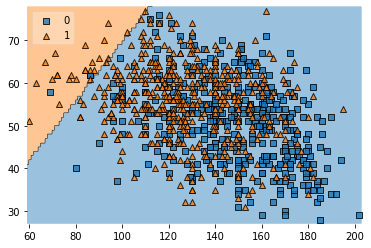

In [25]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(x2.values,y2.values,clf=prc,legend=2)

In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
model= LogisticRegression (solver='liblinear')
pipe= make_pipeline(trans,model)
pipe

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('onehotencoder',
                                                  OneHotEncoder(sparse=False),
                                                  [2, 6, 10]),
                                                 ('ordinalencoder',
                                                  OrdinalEncoder(), [1, 8]),
                                                 ('standardscaler',
                                                  StandardScaler(),
                                                  [0, 3, 4, 5, 7, 9])])),
                ('logisticregression', LogisticRegression(solver='liblinear'))])

In [27]:
pipe.fit(x_train,y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('onehotencoder',
                                                  OneHotEncoder(sparse=False),
                                                  [2, 6, 10]),
                                                 ('ordinalencoder',
                                                  OrdinalEncoder(), [1, 8]),
                                                 ('standardscaler',
                                                  StandardScaler(),
                                                  [0, 3, 4, 5, 7, 9])])),
                ('logisticregression', LogisticRegression(solver='liblinear'))])

In [28]:
prediction = pipe.predict(x_test)

In [29]:
prediction

array([1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0,
       0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1,
       1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1,
       1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1,
       0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0,
       0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0,
       0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0,
       1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1,
       0, 1, 1, 1, 0, 1, 1, 1])

In [30]:
accuracy_score(prediction,y_test)*100

86.41304347826086

In [31]:
from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline
algorithm=SVC()
pipe3= make_pipeline(trans,algorithm)
pipe3

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('onehotencoder',
                                                  OneHotEncoder(sparse=False),
                                                  [2, 6, 10]),
                                                 ('ordinalencoder',
                                                  OrdinalEncoder(), [1, 8]),
                                                 ('standardscaler',
                                                  StandardScaler(),
                                                  [0, 3, 4, 5, 7, 9])])),
                ('svc', SVC())])

In [32]:
pipe3.fit(x_train,y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('onehotencoder',
                                                  OneHotEncoder(sparse=False),
                                                  [2, 6, 10]),
                                                 ('ordinalencoder',
                                                  OrdinalEncoder(), [1, 8]),
                                                 ('standardscaler',
                                                  StandardScaler(),
                                                  [0, 3, 4, 5, 7, 9])])),
                ('svc', SVC())])

In [33]:
prediction3=pipe3.predict(x_test)

In [34]:
accuracy_score(prediction3,y_test)*100

86.41304347826086

/opt/conda/lib/python3.7/site-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


<AxesSubplot:xlabel='HeartDisease', ylabel='count'>

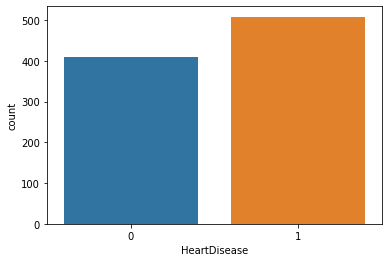

In [35]:
import seaborn as sns
sns.countplot(y)

In [36]:
from imblearn.under_sampling import RandomUnderSampler
under= RandomUnderSampler()
u_x,u_y = under.fit_resample(x,y)
u_y.value_counts()

0    410
1    410
Name: HeartDisease, dtype: int64

In [37]:
from imblearn.over_sampling import RandomOverSampler
under = RandomOverSampler()
u_x, u_y = under.fit_resample(x,y)
u_y.value_counts()

0    508
1    508
Name: HeartDisease, dtype: int64

In [38]:
from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.pipeline import make_pipeline
s = SMOTE()
pipe4 = make_pipeline(trans,s,algorithm)
pipe4

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('onehotencoder',
                                                  OneHotEncoder(sparse=False),
                                                  [2, 6, 10]),
                                                 ('ordinalencoder',
                                                  OrdinalEncoder(), [1, 8]),
                                                 ('standardscaler',
                                                  StandardScaler(),
                                                  [0, 3, 4, 5, 7, 9])])),
                ('smote', SMOTE()), ('svc', SVC())])

In [39]:
pipe4.fit(x_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('onehotencoder',
                                                  OneHotEncoder(sparse=False),
                                                  [2, 6, 10]),
                                                 ('ordinalencoder',
                                                  OrdinalEncoder(), [1, 8]),
                                                 ('standardscaler',
                                                  StandardScaler(),
                                                  [0, 3, 4, 5, 7, 9])])),
                ('smote', SMOTE()), ('svc', SVC())])

In [40]:
prediction4 = pipe4.predict(x_test)
prediction4

array([1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0,
       0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1,
       1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1,
       1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1,
       0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0,
       0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0,
       0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0,
       1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1,
       0, 1, 0, 1, 0, 1, 1, 1])

In [41]:
accuracy_score(prediction4, y_test)*100

86.41304347826086

/opt/conda/lib/python3.7/site-packages/sklearn/utils/deprecation.py:87: FutureWarning: Function plot_confusion_matrix is deprecated; Function `plot_confusion_matrix` is deprecated in 1.0 and will be removed in 1.2. Use one of the class methods: ConfusionMatrixDisplay.from_predictions or ConfusionMatrixDisplay.from_estimator.
  warnings.warn(msg, category=FutureWarning)


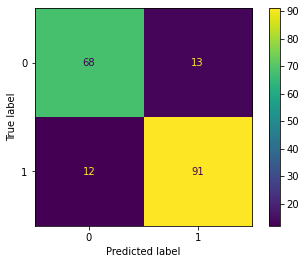

In [42]:
from sklearn.metrics import plot_confusion_matrix
plot_confusion_matrix(pipe4, x_test, y_test)


In [43]:
from sklearn.metrics import accuracy_score
accuracy_score(pred, y_test)*100

87.5

In [44]:
from sklearn.ensemble import VotingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

In [45]:
model2 = KNeighborsClassifier(5)
model3 = SVC()
model4 = LogisticRegression(solver= 'liblinear')
voting = VotingClassifier(estimators = [('x1',model2), ('x2',model3),('x3',model4)],voting = 'hard',verbose=True)
from sklearn.pipeline import make_pipeline
voting_pipe = make_pipeline(trans, voting)

In [46]:
voting_pipe

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('onehotencoder',
                                                  OneHotEncoder(sparse=False),
                                                  [2, 6, 10]),
                                                 ('ordinalencoder',
                                                  OrdinalEncoder(), [1, 8]),
                                                 ('standardscaler',
                                                  StandardScaler(),
                                                  [0, 3, 4, 5, 7, 9])])),
                ('votingclassifier',
                 VotingClassifier(estimators=[('x1', KNeighborsClassifier()),
                                              ('x2', SVC()),
                                              ('x3',
                                               LogisticRegression(solver='liblinear'))],
                                  verbose=True))])

In [47]:
voting_pipe.fit(x_train, y_train)

[Voting] ....................... (1 of 3) Processing x1, total=   0.0s
[Voting] ....................... (2 of 3) Processing x2, total=   0.0s
[Voting] ....................... (3 of 3) Processing x3, total=   0.0s


Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('onehotencoder',
                                                  OneHotEncoder(sparse=False),
                                                  [2, 6, 10]),
                                                 ('ordinalencoder',
                                                  OrdinalEncoder(), [1, 8]),
                                                 ('standardscaler',
                                                  StandardScaler(),
                                                  [0, 3, 4, 5, 7, 9])])),
                ('votingclassifier',
                 VotingClassifier(estimators=[('x1', KNeighborsClassifier()),
                                              ('x2', SVC()),
                                              ('x3',
                                               LogisticRegression(solver='liblinear'))],
                                  verbose=True))])

In [48]:
voting_prediction = voting_pipe.predict(x_test)
voting_prediction

array([1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0,
       0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1,
       1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1,
       1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1,
       0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0,
       0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0,
       0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0,
       1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1,
       0, 1, 1, 1, 0, 1, 1, 1])

In [49]:
accuracy_score(voting_prediction, y_test)*100

88.58695652173914

In [50]:
from sklearn.ensemble import BaggingClassifier
from sklearn.svm import SVC
model15 = SVC()
model16 = BaggingClassifier(base_estimator = SVC())

In [51]:
from sklearn.pipeline import make_pipeline
pipe5 = make_pipeline(trans, model16)
pipe5

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('onehotencoder',
                                                  OneHotEncoder(sparse=False),
                                                  [2, 6, 10]),
                                                 ('ordinalencoder',
                                                  OrdinalEncoder(), [1, 8]),
                                                 ('standardscaler',
                                                  StandardScaler(),
                                                  [0, 3, 4, 5, 7, 9])])),
                ('baggingclassifier', BaggingClassifier(base_estimator=SVC()))])

In [52]:
pipe5.fit(x_train,y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('onehotencoder',
                                                  OneHotEncoder(sparse=False),
                                                  [2, 6, 10]),
                                                 ('ordinalencoder',
                                                  OrdinalEncoder(), [1, 8]),
                                                 ('standardscaler',
                                                  StandardScaler(),
                                                  [0, 3, 4, 5, 7, 9])])),
                ('baggingclassifier', BaggingClassifier(base_estimator=SVC()))])

In [53]:
prediction5 = pipe5.predict(x_test)
prediction5

array([1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0,
       0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1,
       1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1,
       1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1,
       0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0,
       0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0,
       0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0,
       1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1,
       0, 1, 1, 1, 0, 1, 1, 1])

In [54]:
accuracy_score(prediction5, y_test)*100

86.41304347826086

In [55]:
from sklearn.tree import DecisionTreeClassifier
model17 = DecisionTreeClassifier()
pipe6 = make_pipeline(trans,model17)
pipe6

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('onehotencoder',
                                                  OneHotEncoder(sparse=False),
                                                  [2, 6, 10]),
                                                 ('ordinalencoder',
                                                  OrdinalEncoder(), [1, 8]),
                                                 ('standardscaler',
                                                  StandardScaler(),
                                                  [0, 3, 4, 5, 7, 9])])),
                ('decisiontreeclassifier', DecisionTreeClassifier())])

In [56]:
pipe6.fit(x_train,y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('onehotencoder',
                                                  OneHotEncoder(sparse=False),
                                                  [2, 6, 10]),
                                                 ('ordinalencoder',
                                                  OrdinalEncoder(), [1, 8]),
                                                 ('standardscaler',
                                                  StandardScaler(),
                                                  [0, 3, 4, 5, 7, 9])])),
                ('decisiontreeclassifier', DecisionTreeClassifier())])

In [57]:
prediction6 = pipe6.predict(x_test)
prediction6

array([1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0,
       1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1,
       1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1,
       1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1,
       0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0,
       0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0,
       0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0,
       1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 1, 0, 1, 0, 1, 0, 1])

In [58]:
accuracy_score(prediction6,y_test)*100

82.06521739130434

In [59]:
from sklearn.ensemble import RandomForestClassifier
model18 = RandomForestClassifier(n_estimators=300)
pipe7 = make_pipeline(trans, model18)
pipe7

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('onehotencoder',
                                                  OneHotEncoder(sparse=False),
                                                  [2, 6, 10]),
                                                 ('ordinalencoder',
                                                  OrdinalEncoder(), [1, 8]),
                                                 ('standardscaler',
                                                  StandardScaler(),
                                                  [0, 3, 4, 5, 7, 9])])),
                ('randomforestclassifier',
                 RandomForestClassifier(n_estimators=300))])

In [60]:
pipe7.fit(x_train,y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('onehotencoder',
                                                  OneHotEncoder(sparse=False),
                                                  [2, 6, 10]),
                                                 ('ordinalencoder',
                                                  OrdinalEncoder(), [1, 8]),
                                                 ('standardscaler',
                                                  StandardScaler(),
                                                  [0, 3, 4, 5, 7, 9])])),
                ('randomforestclassifier',
                 RandomForestClassifier(n_estimators=300))])

In [61]:
prediction7 = pipe7.predict(x_test)
prediction7

array([1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0,
       0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1,
       1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1,
       1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1,
       0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0,
       0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0,
       0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0,
       1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1,
       0, 1, 1, 1, 0, 1, 1, 1])

In [62]:
accuracy_score(prediction7,y_test)*100

87.5

In [63]:
from sklearn.tree import DecisionTreeClassifier
model19 = DecisionTreeClassifier()
from sklearn.pipeline import make_pipeline
pipe8 = make_pipeline(trans,model19)

In [64]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
params = {'criterion':['gini','entropy'],
         'max_depth':[None,2,6,7,12],
         'min_samples_split':[2,4,7,10],
         'min_samples_leaf':[15,100]}
pipe9 = make_pipeline(trans,GridSearchCV(model19,params,cv=3,n_jobs=-1,verbose=3))
pipe9

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('onehotencoder',
                                                  OneHotEncoder(sparse=False),
                                                  [2, 6, 10]),
                                                 ('ordinalencoder',
                                                  OrdinalEncoder(), [1, 8]),
                                                 ('standardscaler',
                                                  StandardScaler(),
                                                  [0, 3, 4, 5, 7, 9])])),
                ('gridsearchcv',
                 GridSearchCV(cv=3, estimator=DecisionTreeClassifier(),
                              n_jobs=-1,
                              param_grid={'criterion': ['gini', 'entropy'],
                                          'max_depth': [None, 2, 6, 7, 12],
                                          'min_samples_leaf': [15, 100],
                                          'min_samples_split': [2, 4, 7, 10]},
                              verbose=3))])

In [65]:
pipe9.fit(x_train,y_train)

Fitting 3 folds for each of 80 candidates, totalling 240 fits


Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('onehotencoder',
                                                  OneHotEncoder(sparse=False),
                                                  [2, 6, 10]),
                                                 ('ordinalencoder',
                                                  OrdinalEncoder(), [1, 8]),
                                                 ('standardscaler',
                                                  StandardScaler(),
                                                  [0, 3, 4, 5, 7, 9])])),
                ('gridsearchcv',
                 GridSearchCV(cv=3, estimator=DecisionTreeClassifier(),
                              n_jobs=-1,
                              param_grid={'criterion': ['gini', 'entropy'],
                                          'max_depth': [None, 2, 6, 7, 12],
                                          'min_samples_leaf': [15, 100],
                                          'min_samples_split': [2, 4, 7, 10]},
                              verbose=3))])

In [66]:
prediction8 = pipe9.predict(x_test)
prediction8

array([1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0,
       0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1,
       1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1,
       1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1,
       0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0,
       0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0,
       1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1,
       0, 1, 0, 1, 0, 1, 1, 1])

In [67]:
accuracy_score(prediction8, y_test)*100

85.86956521739131

In [68]:
pipe9.named_steps

{'columntransformer': ColumnTransformer(remainder='passthrough',
                   transformers=[('onehotencoder', OneHotEncoder(sparse=False),
                                  [2, 6, 10]),
                                 ('ordinalencoder', OrdinalEncoder(), [1, 8]),
                                 ('standardscaler', StandardScaler(),
                                  [0, 3, 4, 5, 7, 9])]),
 'gridsearchcv': GridSearchCV(cv=3, estimator=DecisionTreeClassifier(), n_jobs=-1,
              param_grid={'criterion': ['gini', 'entropy'],
                          'max_depth': [None, 2, 6, 7, 12],
                          'min_samples_leaf': [15, 100],
                          'min_samples_split': [2, 4, 7, 10]},
              verbose=3)}

In [69]:
pipe9.named_steps['gridsearchcv'].best_params_

{'criterion': 'gini',
 'max_depth': None,
 'min_samples_leaf': 15,
 'min_samples_split': 4}

In [70]:
from sklearn.tree import DecisionTreeClassifier
model20 = DecisionTreeClassifier()
from sklearn.pipeline import make_pipeline
pipe10 = make_pipeline(trans,model20)

In [71]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
params = {'criterion':['gini','entropy'],
         'max_depth':[None],
         'min_samples_split':[2],
         'min_samples_leaf':[15]}
pipe10 = make_pipeline(trans,GridSearchCV(model20,params,cv=3,n_jobs=-1,verbose=3))
pipe10

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('onehotencoder',
                                                  OneHotEncoder(sparse=False),
                                                  [2, 6, 10]),
                                                 ('ordinalencoder',
                                                  OrdinalEncoder(), [1, 8]),
                                                 ('standardscaler',
                                                  StandardScaler(),
                                                  [0, 3, 4, 5, 7, 9])])),
                ('gridsearchcv',
                 GridSearchCV(cv=3, estimator=DecisionTreeClassifier(),
                              n_jobs=-1,
                              param_grid={'criterion': ['gini', 'entropy'],
                                          'max_depth': [None],
                                          'min_samples_leaf': [15],
                                          'min_samples_split': [2]},
                              verbose=3))])

In [72]:
pipe10.fit(x_train,y_train)

Fitting 3 folds for each of 2 candidates, totalling 6 fits


Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('onehotencoder',
                                                  OneHotEncoder(sparse=False),
                                                  [2, 6, 10]),
                                                 ('ordinalencoder',
                                                  OrdinalEncoder(), [1, 8]),
                                                 ('standardscaler',
                                                  StandardScaler(),
                                                  [0, 3, 4, 5, 7, 9])])),
                ('gridsearchcv',
                 GridSearchCV(cv=3, estimator=DecisionTreeClassifier(),
                              n_jobs=-1,
                              param_grid={'criterion': ['gini', 'entropy'],
                                          'max_depth': [None],
                                          'min_samples_leaf': [15],
                                          'min_samples_split': [2]},
                              verbose=3))])

In [73]:
prediction11 = pipe10.predict(x_test)

In [74]:
accuracy_score(prediction11,y_test)*100

85.86956521739131

In [75]:
from sklearn.tree import DecisionTreeClassifier
model21 = DecisionTreeClassifier()
from sklearn.pipeline import make_pipeline
pipe11 = make_pipeline(trans,model21)

In [76]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier
params1 = {'criterion':['gini','entropy'],
         'max_depth':[None,2,10,15,20,25,3,5,7,12],
         'min_samples_split':[2,12,16,19,20,5,10,11,13,15,17],
         'min_samples_leaf':[15,20,25,30,35,36,38,40]}
pipe11 = make_pipeline(trans,RandomizedSearchCV(model21,params1,cv=3,n_jobs=-1,verbose=3))
pipe11

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('onehotencoder',
                                                  OneHotEncoder(sparse=False),
                                                  [2, 6, 10]),
                                                 ('ordinalencoder',
                                                  OrdinalEncoder(), [1, 8]),
                                                 ('standardscaler',
                                                  StandardScaler(),
                                                  [0, 3, 4, 5, 7, 9])])),
                ('randomizedsearchcv',
                 RandomizedSearchCV(cv=3, estimator=DecisionTreeClassifier(),
                                    n_jobs=-1,
                                    param_distributions={'criterion': ['gini',
                                                                       'entropy'],
                                                         'max_depth': [None, 2,
                                                                       10, 15,
                                                                       20, 25,
                                                                       3, 5, 7,
                                                                       12],
                                                         'min_samples_leaf': [15,
                                                                              20,
                                                                              25,
                                                                              30,
                                                                              35,
                                                                              36,
                                                                              38,
                                                                              40],
                                                         'min_samples_split': [2,
                                                                               12,
                                                                               16,
                                                                               19,
                                                                               20,
                                                                               5,
                                                                               10,
                                                                               11,
                                                                               13,
                                                                               15,
                                                                               17]},
                                    verbose=3))])

In [77]:
pipe11.fit(x_train,y_train)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
[CV 2/3] END criterion=gini, max_depth=None, min_samples_leaf=15, min_samples_split=2;, score=0.804 total time=   0.0s
[CV 2/3] END criterion=gini, max_depth=None, min_samples_leaf=15, min_samples_split=4;, score=0.816 total time=   0.0s
[CV 3/3] END criterion=gini, max_depth=None, min_samples_leaf=15, min_samples_split=4;, score=0.840 total time=   0.0s
[CV 1/3] END criterion=gini, max_depth=None, min_samples_leaf=15, min_samples_split=7;, score=0.849 total time=   0.0s
[CV 2/3] END criterion=gini, max_depth=None, min_samples_leaf=15, min_samples_split=7;, score=0.816 total time=   0.0s
[CV 3/3] END criterion=gini, max_depth=None, min_samples_leaf=15, min_samples_split=7;, score=0.840 total time=   0.0s
[CV 1/3] END criterion=gini, max_depth=None, min_samples_leaf=15, min_samples_split=10;, score=0.849 total time=   0.0s
[CV 2/3] END criterion=gini, max_depth=None, min_samples_leaf=15, min_samples_split=10;, score=0.816 tota

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('onehotencoder',
                                                  OneHotEncoder(sparse=False),
                                                  [2, 6, 10]),
                                                 ('ordinalencoder',
                                                  OrdinalEncoder(), [1, 8]),
                                                 ('standardscaler',
                                                  StandardScaler(),
                                                  [0, 3, 4, 5, 7, 9])])),
                ('randomizedsearchcv',
                 RandomizedSearchCV(cv=3, estimator=DecisionTreeClassifier(),
                                    n_jobs=-1,
                                    param_distributions={'criterion': ['gini',
                                                                       'entropy'],
                                                         'max_depth': [None, 2,
                                                                       10, 15,
                                                                       20, 25,
                                                                       3, 5, 7,
                                                                       12],
                                                         'min_samples_leaf': [15,
                                                                              20,
                                                                              25,
                                                                              30,
                                                                              35,
                                                                              36,
                                                                              38,
                                                                              40],
                                                         'min_samples_split': [2,
                                                                               12,
                                                                               16,
                                                                               19,
                                                                               20,
                                                                               5,
                                                                               10,
                                                                               11,
                                                                               13,
                                                                               15,
                                                                               17]},
                                    verbose=3))])

In [78]:
prediction12= pipe11.predict(x_test)
prediction12

array([1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0,
       0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1,
       1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1,
       1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1,
       0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0,
       0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0,
       0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0,
       1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1,
       0, 1, 0, 1, 0, 1, 1, 1])

In [79]:
accuracy_score(prediction12,y_test)*100

84.78260869565217

In [80]:
pipe11.named_steps['randomizedsearchcv'].best_params_

{'min_samples_split': 19,
 'min_samples_leaf': 25,
 'max_depth': 25,
 'criterion': 'entropy'}

In [81]:
from sklearn.tree import DecisionTreeClassifier
model22 = DecisionTreeClassifier()
from sklearn.pipeline import make_pipeline
pipe12 = make_pipeline(trans,model22)

In [82]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier
params1 = {'criterion':['entropy'],
         'max_depth':[5],
         'min_samples_split':[20],
         'min_samples_leaf':[30]}
pipe12 = make_pipeline(trans,RandomizedSearchCV(model22,params1,cv=3,n_jobs=-1,verbose=3))
pipe12

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('onehotencoder',
                                                  OneHotEncoder(sparse=False),
                                                  [2, 6, 10]),
                                                 ('ordinalencoder',
                                                  OrdinalEncoder(), [1, 8]),
                                                 ('standardscaler',
                                                  StandardScaler(),
                                                  [0, 3, 4, 5, 7, 9])])),
                ('randomizedsearchcv',
                 RandomizedSearchCV(cv=3, estimator=DecisionTreeClassifier(),
                                    n_jobs=-1,
                                    param_distributions={'criterion': ['entropy'],
                                                         'max_depth': [5],
                                                         'min_samples_leaf': [30],
                                                         'min_samples_split': [20]},
                                    verbose=3))])

In [83]:
pipe12.fit(x_train,y_train)

Fitting 3 folds for each of 1 candidates, totalling 3 fits
[CV 1/3] END criterion=gini, max_depth=None, min_samples_leaf=15, min_samples_split=4;, score=0.849 total time=   0.0s
[CV 1/3] END criterion=gini, max_depth=None, min_samples_leaf=100, min_samples_split=4;, score=0.849 total time=   0.0s
[CV 3/3] END criterion=gini, max_depth=None, min_samples_leaf=100, min_samples_split=4;, score=0.803 total time=   0.0s
[CV 1/3] END criterion=gini, max_depth=None, min_samples_leaf=100, min_samples_split=10;, score=0.849 total time=   0.0s
[CV 2/3] END criterion=gini, max_depth=2, min_samples_leaf=15, min_samples_split=2;, score=0.820 total time=   0.0s
[CV 1/3] END criterion=gini, max_depth=2, min_samples_leaf=15, min_samples_split=7;, score=0.849 total time=   0.0s
[CV 2/3] END criterion=gini, max_depth=2, min_samples_leaf=15, min_samples_split=7;, score=0.820 total time=   0.0s
[CV 3/3] END criterion=gini, max_depth=2, min_samples_leaf=100, min_samples_split=2;, score=0.803 total time=   0

/opt/conda/lib/python3.7/site-packages/sklearn/model_selection/_search.py:296: UserWarning: The total space of parameters 1 is smaller than n_iter=10. Running 1 iterations. For exhaustive searches, use GridSearchCV.
  UserWarning,


Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('onehotencoder',
                                                  OneHotEncoder(sparse=False),
                                                  [2, 6, 10]),
                                                 ('ordinalencoder',
                                                  OrdinalEncoder(), [1, 8]),
                                                 ('standardscaler',
                                                  StandardScaler(),
                                                  [0, 3, 4, 5, 7, 9])])),
                ('randomizedsearchcv',
                 RandomizedSearchCV(cv=3, estimator=DecisionTreeClassifier(),
                                    n_jobs=-1,
                                    param_distributions={'criterion': ['entropy'],
                                                         'max_depth': [5],
                                                         'min_samples_leaf': [30],
                                                         'min_samples_split': [20]},
                                    verbose=3))])

In [84]:
prediction13= pipe12.predict(x_test)
prediction13

array([1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0,
       0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1,
       1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1,
       1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1,
       0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0,
       0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0,
       0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0,
       1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1,
       0, 1, 0, 1, 0, 1, 1, 1])

In [85]:
accuracy_score(prediction13,y_test)*100

84.78260869565217